###Camada Gold

###Imports necessários

In [0]:
# Imports necessários

from pyspark.sql import SparkSession
# from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.functions import col, trim, regexp_extract, to_date, when
from pyspark.sql.functions import current_timestamp, explode, split, row_number, lit
from pyspark.sql.window import Window
from pyspark.sql.functions import dayofmonth, month, date_format, year, quarter, dayofweek
from delta.tables import DeltaTable
import matplotlib.pyplot as plt 	
import seaborn as sns
import gc			



###Limpeza de cache e tratamento de lixo

In [0]:
spark.catalog.clearCache()

In [0]:
gc.collect()

Out[152]: 606

###Sessão Spark

In [0]:
# Importar as bibliotecas necessárias
#from pyspark.sql import SparkSession
#from pyspark.sql.functions import *
#from pyspark.sql.types import *

# Iniciar a SparkSession com configurações otimizadas
spark = SparkSession.builder \
    .appName("Camada Gold - flocos de neve") \
    .config("spark.sql.shuffle.partitions", "4")  \
    .config("spark.sql.files.maxPartitionBytes", "128MB") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()


###Criação do database gold e exibição de schemas

In [0]:
%sql
-- Drop the database using IF EXISTS
-- DROP DATABASE CASCADE - deleta um database e suas tabelas 
DROP DATABASE IF EXISTS gold CASCADE;

###Recriação do database gold

In [0]:
%sql CREATE DATABASE gold;

In [0]:
%sql SHOW SCHEMAS;

databaseName
bronze
default
gold
silver


In [0]:
%sql USE gold;

In [0]:
%sql SHOW tables;

database,tableName,isTemporary


####Remoção e criação de pastas n camada gold

In [0]:
gold_path = "/mnt/netflix/gold"
dbutils.fs.rm(gold_path,recurse=True)
dbutils.fs.mkdirs(gold_path)

Out[159]: True

###Leitura  da camada silver e criação de tabelas na camada gold

Leitura de tabelas da camada silver, criando as mesmas na camada gold e persistindo em formato delta. As tabelas da camada gold manterão a mesma estrutura da camada silver.

### Criação das tabelas de dimensão

In [0]:
# from pyspark.sql.functions import current_timestamp, explode, split

# Tabela  1 – dim_date
tabela_dim_date = "dim_date"
gold_dim_date_df = spark.read.table("silver.dim_date")

#gera dataframe dim_date

gold_dim_date_df = (gold_dim_date_df
  .select(
      "date_added",
      "day",
      "month",
      "month_name",
      "year",
      "quarter",
      "day_of_week",
      "day_name",
      "is_weekend",
  ))

# Exibe dataframe
gold_dim_date_df.show()

# Escrever usando API DeltaTable
DeltaTable.createIfNotExists(spark) \
    .tableName("gold.dim_date") \
    .addColumns(gold_dim_date_df.schema) \
    .partitionedBy("year") \
    .location(f"{gold_path}/{tabela_dim_date}") \
    .execute()
    
gold_dim_date_df.write.format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("gold.dim_date")

spark.sql("ALTER TABLE gold.dim_date ALTER COLUMN date_added COMMENT 'data cadastrado na Netflix'")
spark.sql("ALTER TABLE gold.dim_date ALTER COLUMN day COMMENT 'dia'")
spark.sql("ALTER TABLE gold.dim_date ALTER COLUMN month COMMENT 'mes'")
spark.sql("ALTER TABLE gold.dim_date ALTER COLUMN month_name COMMENT 'nome do mes'")
spark.sql("ALTER TABLE gold.dim_date ALTER COLUMN year COMMENT 'ano'")
spark.sql("ALTER TABLE gold.dim_date ALTER COLUMN quarter COMMENT 'trimestre'")
spark.sql("ALTER TABLE gold.dim_date ALTER COLUMN day_of_week COMMENT 'dia da semana'")
spark.sql("ALTER TABLE gold.dim_date ALTER COLUMN day_name COMMENT 'nome do dia'")
spark.sql("ALTER TABLE gold.dim_date ALTER COLUMN is_weekend COMMENT 'fim de semana ou nao'")


+----------+---+-----+----------+----+-------+-----------+---------+----------+
|date_added|day|month|month_name|year|quarter|day_of_week| day_name|is_weekend|
+----------+---+-----+----------+----+-------+-----------+---------+----------+
|2014-12-05|  5|   12|  December|2014|      4|          6|   Friday|     false|
|2014-11-07|  7|   11|  November|2014|      4|          6|   Friday|     false|
|2014-10-21| 21|   10|   October|2014|      4|          3|  Tuesday|     false|
|2014-09-26| 26|    9| September|2014|      3|          6|   Friday|     false|
|2014-08-15| 15|    8|    August|2014|      3|          6|   Friday|     false|
|2014-04-15| 15|    4|     April|2014|      2|          3|  Tuesday|     false|
|2014-02-01|  1|    2|  February|2014|      1|          7| Saturday|      true|
|2014-01-24| 24|    1|   January|2014|      1|          6|   Friday|     false|
|2014-12-12| 12|   12|  December|2014|      4|          6|   Friday|     false|
|2014-02-16| 16|    2|  February|2014|  

In [0]:
%sql SELECT * FROM gold.dim_date;

date_added,day,month,month_name,year,quarter,day_of_week,day_name,is_weekend
2019-12-31,31,12,December,2019,4,3,Tuesday,false
2019-12-28,28,12,December,2019,4,7,Saturday,true
2019-12-26,26,12,December,2019,4,5,Thursday,false
2019-12-21,21,12,December,2019,4,7,Saturday,true
2019-12-19,19,12,December,2019,4,5,Thursday,false
2019-12-18,18,12,December,2019,4,4,Wednesday,false
2019-12-12,12,12,December,2019,4,5,Thursday,false
2019-12-09,9,12,December,2019,4,2,Monday,false
2019-12-08,8,12,December,2019,4,1,Sunday,true
2019-12-03,3,12,December,2019,4,3,Tuesday,false


####Criação da tabela dim_pais

In [0]:
# Tabela 2 – dim_pais

tabela_dim_pais =  "dim_pais"
gold_dim_pais_df = spark.read.table("silver.dim_pais")

#gera dataframe dim_pais

gold_dim_pais_df = (gold_dim_pais_df
  .select(
      "country",
      "country_id"
  ))

# Exibe dataframe
gold_dim_pais_df.show()

# Escrever usando API DeltaTable
DeltaTable.createIfNotExists(spark) \
    .tableName("gold.dim_pais") \
    .addColumns(gold_dim_pais_df.schema) \
    .location(f"{gold_path}/{tabela_dim_pais}") \
    .execute()
    
gold_dim_pais_df.write.format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("gold.dim_pais")

# Adiciona comentários às colunas usando SQL
spark.sql("ALTER TABLE gold.dim_pais ALTER COLUMN country COMMENT 'pais'")
spark.sql("ALTER TABLE gold.dim_pais ALTER COLUMN country_id COMMENT 'identificador de pais'")

# Verifica se os comentários foram aplicados em linhas das tabelas

display(spark.sql("DESCRIBE EXTENDED gold.dim_pais"))

+------------+----------+
|     country|country_id|
+------------+----------+
| Afghanistan|         2|
|     Albania|         3|
|     Algeria|         4|
|      Angola|         5|
|   Argentina|         6|
|     Armenia|         7|
|   Australia|         8|
|     Austria|         9|
|  Azerbaijan|        10|
|     Bahamas|        11|
|  Bangladesh|        12|
|     Belarus|        13|
|     Belgium|        14|
|     Bermuda|        15|
|    Botswana|        16|
|      Brazil|        17|
|    Bulgaria|        18|
|Burkina Faso|        19|
|    Cambodia|        20|
|    Cameroon|        21|
+------------+----------+
only showing top 20 rows



col_name,data_type,comment
country,string,pais
country_id,int,identificador de pais
,,
# Detailed Table Information,,
Catalog,spark_catalog,
Database,gold,
Table,dim_pais,
Created Time,Fri Apr 11 21:32:03 UTC 2025,
Last Access,UNKNOWN,
Created By,Spark 3.3.2,


In [0]:
%sql
SELECT * FROM gold.dim_pais LIMIT 10;


country,country_id
Afghanistan,2
Albania,3
Algeria,4
Angola,5
Argentina,6
Armenia,7
Australia,8
Austria,9
Azerbaijan,10
Bahamas,11


In [0]:
# Tabela 3 – dim_ator
tabela_dim_ator = "dim_ator"
gold_dim_ator_df = spark.read.table("silver.dim_ator")

#gera dataframe dim_ator

gold_dim_ator_df = (gold_dim_ator_df
  .select(
      "cast",
      "ator_id"
  ))

# Exibe dataframe
gold_dim_ator_df.show()

# Escrever usando API DeltaTable
DeltaTable.createIfNotExists(spark) \
    .tableName("gold.dim_ator") \
    .addColumns(gold_dim_ator_df.schema) \
    .location(f"{gold_path}/{tabela_dim_ator}") \
    .execute()
    
gold_dim_ator_df.write.format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("gold.dim_ator")

spark.sql("ALTER TABLE gold.dim_ator ALTER COLUMN ator_id COMMENT 'identificador do ator'")
spark.sql("ALTER TABLE gold.dim_ator ALTER COLUMN cast COMMENT 'nome do ator'")



+--------------------+-------+
|                cast|ator_id|
+--------------------+-------+
|"Riley" Lakdhar D...|      1|
|        'Najite Dede|      2|
|            2 Chainz|      3|
|                2Mex|      4|
|             4Minute|      5|
|             50 Cent|      6|
|                9m88|      7|
|A Boogie Wit tha ...|      8|
|      A. Murat Özgen|      9|
|       A.C. Peterson|     10|
|          A.D. Miles|     11|
|           A.J. Cook|     12|
|        A.J. Johnson|     13|
|       A.J. LoCascio|     14|
|         A.K. Hangal|     15|
|         A.R. Rahman|     16|
|     A.S. Sasi Kumar|     17|
|              AC Lim|     18|
|                AFRA|     19|
|            AJ Bowen|     20|
+--------------------+-------+
only showing top 20 rows

Out[164]: DataFrame[]

In [0]:
%sql 
SELECT * FROM gold.dim_ator LIMIT 10;

cast,ator_id
"""Riley"" Lakdhar Dridi",1
'Najite Dede,2
2 Chainz,3
2Mex,4
4Minute,5
50 Cent,6
9m88,7
A Boogie Wit tha Hoodie,8
A. Murat Özgen,9
A.C. Peterson,10


In [0]:
# Tabela 4 – dim_genero
tabela_dim_genero = "dim_genero"
gold_dim_genero_df = spark.read.table("silver.dim_genero")

#gera dataframe dim_genero

gold_dim_genero_df = (gold_dim_genero_df
  .select(
      "genre",
      "genre_id"
  ))

# Exibe dataframe
gold_dim_genero_df.show()

# Escrever usando API DeltaTable
DeltaTable.createIfNotExists(spark) \
    .tableName("gold.dim_genero") \
    .addColumns(gold_dim_genero_df.schema) \
    .location(f"{gold_path}/{tabela_dim_genero}") \
    .execute()
    
gold_dim_genero_df.write.format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("gold.dim_genero")

spark.sql("ALTER TABLE gold.dim_genero ALTER COLUMN genre COMMENT 'genero'")
spark.sql("ALTER TABLE gold.dim_genero ALTER COLUMN genre_id COMMENT 'identificador de genero'")



+--------------------+--------+
|               genre|genre_id|
+--------------------+--------+
|  Action & Adventure|       1|
|      Anime Features|       2|
|        Anime Series|       3|
|    British TV Shows|       4|
|Children & Family...|       5|
|   Classic & Cult TV|       6|
|      Classic Movies|       7|
|            Comedies|       8|
|      Crime TV Shows|       9|
|         Cult Movies|      10|
|       Documentaries|      11|
|          Docuseries|      12|
|              Dramas|      13|
|Faith & Spirituality|      14|
|       Horror Movies|      15|
|  Independent Movies|      16|
|International Movies|      17|
|International TV ...|      18|
|            Kids' TV|      19|
|     Korean TV Shows|      20|
+--------------------+--------+
only showing top 20 rows

Out[166]: DataFrame[]

In [0]:
%sql select * FROM gold.dim_genero LIMIT 20;

genre,genre_id
Action & Adventure,1
Anime Features,2
Anime Series,3
British TV Shows,4
Children & Family Movies,5
Classic & Cult TV,6
Classic Movies,7
Comedies,8
Crime TV Shows,9
Cult Movies,10


In [0]:
# Tabela 5 – dim_diretor
tabela_dim_diretor = "dim_diretor"
gold_dim_diretor_df = spark.read.table("silver.dim_diretor")

#gera dataframe dim_diretor

gold_dim_diretor_df = (gold_dim_diretor_df
  .select(
      "director",
      "director_id"
  ))

# Exibe dataframe
gold_dim_diretor_df.show()

# Escrever usando API DeltaTable
DeltaTable.createIfNotExists(spark) \
    .tableName("gold.dim_diretor") \
    .addColumns(gold_dim_diretor_df.schema) \
    .location(f"{gold_path}/{tabela_dim_diretor}") \
    .execute()
    
gold_dim_diretor_df.write.format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("gold.dim_diretor")

spark.sql("ALTER TABLE gold.dim_diretor ALTER COLUMN director COMMENT 'nome do diretor'")
spark.sql("ALTER TABLE gold.dim_diretor ALTER COLUMN director_id COMMENT 'identificador de diretor'")


+--------------------+-----------+
|            director|director_id|
+--------------------+-----------+
|         A. L. Vijay|          1|
|        A. Raajdheep|          2|
|           A. Salaam|          3|
|     A.R. Murugadoss|          4|
|     Aadish Keluskar|          5|
|        Aamir Bashir|          6|
|          Aamir Khan|          7|
|          Aanand Rai|          8|
|         Aaron Burns|          9|
|        Aaron Hancox|         10|
|          Aaron Hann|         11|
|        Aaron Lieber|         12|
|      Aaron Moorhead|         13|
|           Aaron Nee|         14|
|        Aaron Sorkin|         15|
|       Aaron Woodley|         16|
|         Aaron Woolf|         17|
|     Aatmaram Dharne|         18|
|      Abba T. Makama|         19|
|Abbas Alibhai Bur...|         20|
+--------------------+-----------+
only showing top 20 rows

Out[168]: DataFrame[]

In [0]:
%sql SELECT * FROM gold.dim_diretor;


director,director_id
A. L. Vijay,1
A. Raajdheep,2
A. Salaam,3
A.R. Murugadoss,4
Aadish Keluskar,5
Aamir Bashir,6
Aamir Khan,7
Aanand Rai,8
Aaron Burns,9
Aaron Hancox,10


In [0]:


# Tabela 6 - Cria a tabela dim_tipo_conteudo

gold_dim_tipo_conteudo_df = spark.read.table("silver.dim_tipo_conteudo")
tabela_dim_tipo_conteudo= "dim_tipo_conteudo"

dim_tipo_conteudo_df = (gold_dim_tipo_conteudo_df
  .select(
      "content_type_id",
      "content_type",
      "description"
  ))


dim_tipo_conteudo_df.show()

# Escreve a tabela Gold com substituição de esquema
gold_dim_tipo_conteudo_df.write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .option("path", f"{gold_path}/{tabela_dim_tipo_conteudo}") \
    .saveAsTable("gold.dim_tipo_conteudo")

spark.sql("ALTER TABLE gold.dim_tipo_conteudo ALTER COLUMN content_type_id COMMENT 'id tipo de conteudo'")
spark.sql("ALTER TABLE gold.dim_tipo_conteudo ALTER COLUMN content_type COMMENT 'tipo de conteudo'")
spark.sql("ALTER TABLE gold.dim_tipo_conteudo ALTER COLUMN description COMMENT 'descricao tipo de conteudo'")


+---------------+------------+--------------------+
|content_type_id|content_type|         description|
+---------------+------------+--------------------+
|              2|     TV Show|Television series...|
|              1|       Movie|Feature films and...|
+---------------+------------+--------------------+

Out[170]: DataFrame[]

In [0]:
%sql SELECT * FROM gold.dim_tipo_conteudo;

content_type_id,content_type,description
2,TV Show,Television series and shows
1,Movie,Feature films and movies


###Criação da tabela fato Netflix

In [0]:
# Deleta e recria a pasta em que foi armazenada a tabela netflix_fato
dbutils.fs.rm("dbfs:/mnt/netflix/gold/fato Netflix",recurse=True)
dbutils.fs.mkdirs("dbfs:/mnt/netflix/gold/fato Netflix")

Out[172]: True

In [0]:
%sql
-- Deleta a tabela gold.fato_netflix para recriá-la porque estva apresentando erro.
DROP TABLE IF EXISTS gold.fato_netflix;

In [0]:
# Tabela 7 – fato_netflix
tabela_fato_netflix = "fato_netflix"
gold_fato_netflix_df = spark.read.table("silver.fato_netflix")

#gera dataframe fato_netflix

gold_fato_netflix_df = (gold_fato_netflix_df
  .select(
      "show_id",
      "title",
      "content_type_id",
      "date_added",
      "release_year",
      "duration_minutes",
      "duration_seasons",
      "rating",
      "description"
  ))

# Exibe dataframe
gold_fato_netflix_df.show()

# Escrever usando API DeltaTable
DeltaTable.createIfNotExists(spark) \
    .tableName("gold.fato_netflix") \
    .addColumns(gold_fato_netflix_df.schema) \
    .location(f"{gold_path}/{tabela_fato_netflix}") \
    .execute()
    
gold_fato_netflix_df.write.format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("gold.fato_netflix")

spark.sql("ALTER TABLE gold.fato_netflix ALTER COLUMN show_id COMMENT 'identificador de show'")
spark.sql("ALTER TABLE gold.fato_netflix ALTER COLUMN title COMMENT 'titulo'")
spark.sql("ALTER TABLE gold.fato_netflix ALTER COLUMN content_type_id COMMENT 'identificador de tipo de conteudo'")
spark.sql("ALTER TABLE gold.fato_netflix ALTER COLUMN date_added COMMENT 'data cadastrado na Netflix'")
spark.sql("ALTER TABLE gold.fato_netflix ALTER COLUMN release_year COMMENT 'ano de lancamento do filme ou seriado'")
spark.sql("ALTER TABLE gold.fato_netflix ALTER COLUMN duration_minutes COMMENT 'duracao em minutos do filme'")
spark.sql("ALTER TABLE gold.fato_netflix ALTER COLUMN duration_seasons COMMENT 'duracao em temporadas do seriado'")
spark.sql("ALTER TABLE gold.fato_netflix ALTER COLUMN rating COMMENT 'classificacao da faixa etaria'")
spark.sql("ALTER TABLE gold.fato_netflix ALTER COLUMN description COMMENT 'descricao do titulo'")



+-------+--------------------+---------------+----------+------------+----------------+----------------+------+--------------------+
|show_id|               title|content_type_id|date_added|release_year|duration_minutes|duration_seasons|rating|         description|
+-------+--------------------+---------------+----------+------------+----------------+----------------+------+--------------------+
|     s1|Dick Johnson Is Dead|              1|2021-09-25|        2020|              90|            null| PG-13|As her father nea...|
|     s2|       Blood & Water|              2|2021-09-24|        2021|            null|               2| TV-MA|After crossing pa...|
|     s3|           Ganglands|              2|2021-09-24|        2021|            null|               1| TV-MA|To protect his fa...|
|     s4|Jailbirds New Orl...|              2|2021-09-24|        2021|            null|               1| TV-MA|Feuds, flirtation...|
|     s5|        Kota Factory|              2|2021-09-24|        2021

In [0]:
%sql SELECT * FROM gold.fato_netflix LIMIT 20;

show_id,title,content_type_id,date_added,release_year,duration_minutes,duration_seasons,rating,description
s1,Dick Johnson Is Dead,1,2021-09-25,2020,90,null,PG-13,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable."
s2,Blood & Water,2,2021-09-24,2021,null,2,TV-MA,"After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth."
s3,Ganglands,2,2021-09-24,2021,null,1,TV-MA,"To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war."
s4,Jailbirds New Orleans,2,2021-09-24,2021,null,1,TV-MA,"Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series."
s5,Kota Factory,2,2021-09-24,2021,null,2,TV-MA,"In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life."
s6,Midnight Mass,2,2021-09-24,2021,null,1,TV-MA,"The arrival of a charismatic young priest brings glorious miracles, ominous mysteries and renewed religious fervor to a dying town desperate to believe."
s7,My Little Pony: A New Generation,1,2021-09-24,2021,91,null,PG,"Equestria's divided. But a bright-eyed hero believes Earth Ponies, Pegasi and Unicorns should be pals — and, hoof to heart, she’s determined to prove it."
s8,Sankofa,1,2021-09-24,1993,125,null,TV-MA,"On a photo shoot in Ghana, an American model slips back in time, becomes enslaved on a plantation and bears witness to the agony of her ancestral past."
s9,The Great British Baking Show,2,2021-09-24,2021,null,9,TV-14,"A talented batch of amateur bakers face off in a 10-week competition, whipping up their best dishes in the hopes of being named the U.K.'s best."
s10,The Starling,1,2021-09-24,2021,104,null,PG-13,A woman adjusting to life after a loss contends with a feisty bird that's taken over her garden — and a husband who's struggling to find a way forward.


###Criação das tabelas de junção

As tabelas de junção são utilizadas nos relacionamentos muitos para muitos.

In [0]:
# Tabela 8 – conteudo_ator_junc
tabela_conteudo_ator_junc = "conteudo_ator_junc"
gold_conteudo_ator_junc_df = spark.read.table("silver.conteudo_ator_junc")

#gera dataframe conteudo_ator_junc

gold_conteudo_ator_junc_df = (gold_conteudo_ator_junc_df
  .select(
      "show_id",
      "ator_id"
  ))

# Exibe dataframe
gold_conteudo_ator_junc_df.show()

# Escrever usando API DeltaTable
DeltaTable.createIfNotExists(spark) \
    .tableName("gold.conteudo_ator_junc") \
    .addColumns(gold_conteudo_ator_junc_df.schema) \
    .location(f"{gold_path}/{tabela_conteudo_ator_junc}") \
    .execute()
    
gold_conteudo_ator_junc_df.write.format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("gold.conteudo_ator_junc")

spark.sql("ALTER TABLE gold.conteudo_ator_junc ALTER COLUMN show_id COMMENT 'identificador de show'")
spark.sql("ALTER TABLE gold.conteudo_ator_junc ALTER COLUMN ator_id COMMENT 'identificador de ator'")


+-------+-------+
|show_id|ator_id|
+-------+-------+
|  s2138|      1|
|  s2196|      2|
|  s2103|      2|
|  s4962|      3|
|  s1328|      4|
|  s5998|      5|
|  s8465|      6|
|  s8315|      6|
|  s7986|      6|
|  s7869|      6|
|  s6593|      6|
|   s340|      7|
|  s4962|      8|
|  s3924|      9|
|  s7842|     10|
|  s5901|     11|
|  s5346|     11|
|  s2106|     11|
|  s6755|     12|
|  s5413|     12|
+-------+-------+
only showing top 20 rows

Out[176]: DataFrame[]

In [0]:
# Tabela 9 – conteudo_pais_junc
tabela_conteudo_pais_junc = "conteudo_pais_junc"
gold_conteudo_pais_junc_df = spark.read.table("silver.conteudo_pais_junc")

#gera dataframe conteudo_pais_junc

gold_conteudo_pais_junc_df = (gold_conteudo_pais_junc_df
  .select(
      "show_id",
      "country_id"
  ))

# Exibe dataframe
gold_conteudo_pais_junc_df.show()

# Escrever usando API DeltaTable
DeltaTable.createIfNotExists(spark) \
    .tableName("gold.conteudo_pais_junc") \
    .addColumns(gold_conteudo_pais_junc_df.schema) \
    .location(f"{gold_path}/{tabela_conteudo_pais_junc}") \
    .execute()
    
gold_conteudo_pais_junc_df.write.format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("gold.conteudo_pais_junc")

spark.sql("ALTER TABLE gold.conteudo_pais_junc ALTER COLUMN show_id COMMENT 'identificador de show'")
spark.sql("ALTER TABLE gold.conteudo_pais_junc ALTER COLUMN country_id COMMENT 'identificador de pais'")


+-------+----------+
|show_id|country_id|
+-------+----------+
|     s1|       117|
|     s2|       101|
|     s5|        47|
|     s8|       117|
|     s8|        41|
|     s8|        19|
|     s8|       116|
|     s8|        40|
|     s8|        36|
|     s9|       116|
|    s10|       117|
|    s13|        40|
|    s13|        30|
|    s16|       117|
|    s18|        69|
|    s22|       112|
|    s25|        47|
|    s26|         8|
|    s28|       117|
|    s29|       117|
+-------+----------+
only showing top 20 rows

Out[177]: DataFrame[]

In [0]:
# Tabela 10 – conteudo_genero_junc
tabela_conteudo_genero_junc = "conteudo_genero_junc"
gold_conteudo_genero_junc_df = spark.read.table("silver.conteudo_genero_junc")

#gera dataframe conteudo_genero_junc

gold_conteudo_genero_junc_df = (gold_conteudo_genero_junc_df
  .select(
      "show_id",
      "genre_id"
  ))

# Exibe dataframe
gold_conteudo_genero_junc_df.show()

# Escrever usando API DeltaTable
DeltaTable.createIfNotExists(spark) \
    .tableName("gold.conteudo_genero_junc") \
    .addColumns(gold_conteudo_genero_junc_df.schema) \
    .location(f"{gold_path}/{tabela_conteudo_genero_junc}") \
    .execute()
    
gold_conteudo_genero_junc_df.write.format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("gold.conteudo_genero_junc")

spark.sql("ALTER TABLE gold.conteudo_genero_junc ALTER COLUMN show_id COMMENT 'identificador de show'")
spark.sql("ALTER TABLE gold.conteudo_genero_junc ALTER COLUMN genre_id COMMENT 'identificador de genero'")


+-------+--------+
|show_id|genre_id|
+-------+--------+
|     s1|      11|
|     s2|      18|
|     s2|      35|
|     s2|      37|
|     s3|       9|
|     s3|      18|
|     s3|      33|
|     s4|      12|
|     s4|      24|
|     s5|      18|
|     s5|      26|
|     s5|      34|
|     s6|      35|
|     s6|      36|
|     s6|      37|
|     s7|       5|
|     s8|      13|
|     s8|      16|
|     s8|      17|
|     s9|       4|
+-------+--------+
only showing top 20 rows

Out[178]: DataFrame[]

In [0]:
# Tabela 11 – conteudo_diretor_junc
tabela_conteudo_diretor_junc = "conteudo_diretor_junc"
gold_conteudo_diretor_junc_df = spark.read.table("silver.conteudo_diretor_junc")

#gera dataframe conteudo_genero_junc

gold_conteudo_diretor_junc_df = (gold_conteudo_diretor_junc_df
  .select(
      "show_id",
      "director_id"
  ))

# Exibe dataframe
gold_conteudo_diretor_junc_df.show()

# Escrever usando API DeltaTable
DeltaTable.createIfNotExists(spark) \
    .tableName("gold.conteudo_diretor_junc") \
    .addColumns(gold_conteudo_diretor_junc_df.schema) \
    .location(f"{gold_path}/{tabela_conteudo_diretor_junc}") \
    .execute()
    
gold_conteudo_diretor_junc_df.write.format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("gold.conteudo_diretor_junc")

spark.sql("ALTER TABLE gold.conteudo_diretor_junc ALTER COLUMN show_id COMMENT 'identificador de show'")
spark.sql("ALTER TABLE gold.conteudo_diretor_junc ALTER COLUMN director_id COMMENT 'identificador de diretor'")


+-------+-----------+
|show_id|director_id|
+-------+-----------+
|     s1|       2533|
|     s3|       2323|
|     s6|       3163|
|     s7|       3917|
|     s7|       2290|
|     s8|       1646|
|     s9|        335|
|    s10|       4583|
|    s12|       2544|
|    s13|        873|
|    s14|        695|
|    s17|       3579|
|    s17|       3472|
|    s19|         65|
|    s21|       3435|
|    s23|       2371|
|    s24|        190|
|    s24|       4365|
|    s25|       4039|
|    s27|       3752|
+-------+-----------+
only showing top 20 rows

Out[179]: DataFrame[]

##Consultas SQL


###Consultas Analíticas

#### Distribuição de Conteúdo por Tipo e Ano

A consulta exibe a distribuição de conteúdo, agrupada por tipo de conteúdo ("Movie" ou "TV Show") e ano de lançamento.

São exibidos os valores totais de cada tipo de contéudo e duração média.

Se for filme ("Movie"), a duração é expressa em minutos. Se o tipo de conteúdo for "TV Show", a duração é expressa em número de temporadas

In [0]:
%sql
SELECT 
    f.release_year,
    ct.content_type,
    COUNT(*) AS total_por_conteudo,
    ROUND(AVG(f.duration_minutes), 1) AS duracao_media_min_filme,
    ROUND(AVG(f.duration_seasons), 1) AS duracao_media_temporadas_tv_show
FROM gold.fato_netflix f
JOIN gold.dim_tipo_conteudo ct ON f.content_type_id = ct.content_type_id
GROUP BY f.release_year, ct.content_type
ORDER BY f.release_year DESC;

release_year,content_type,total_por_conteudo,duracao_media_min_filme,duracao_media_temporadas_tv_show
2021,TV Show,315,null,1.7
2021,Movie,277,96.4,null
2020,Movie,517,92.1,null
2020,TV Show,436,null,1.7
2019,Movie,633,93.5,null
2019,TV Show,397,null,1.9
2018,TV Show,380,null,1.7
2018,Movie,767,96.2,null
2017,TV Show,265,null,1.8
2017,Movie,767,95.5,null


#### Países com mais produções por gênero

In [0]:
%sql
SELECT 
    c.country,
    g.genre,
    COUNT(*) AS total_conteudo
FROM gold.conteudo_pais_junc jc
JOIN gold.dim_pais c ON jc.country_id = c.country_id
JOIN gold.conteudo_genero_junc jg ON jc.show_id = jg.show_id
JOIN gold.dim_genero g ON jg.genre_id = g.genre_id
GROUP BY c.country, g.genre
ORDER BY total_conteudo DESC;

country,genre,total_conteudo
India,International Movies,864
United States,Dramas,835
United States,Comedies,680
India,Dramas,662
United States,Documentaries,512
United States,Action & Adventure,404
United States,Independent Movies,390
United States,Children & Family Movies,390
India,Comedies,323
United States,Thrillers,292


###Análise Temporal

####Conteúdo Adicionado por Ano/Mês

In [0]:
%sql
-- Conteudo adicionado por ano / mes
SELECT 
    d.year,
    d.month,
    ct.content_type,
    COUNT(*) AS added_content
FROM gold.fato_netflix f
JOIN gold.dim_date d ON f.date_added = d.date_added
JOIN gold.dim_tipo_conteudo ct ON f.content_type_id = ct.content_type_id
GROUP BY d.year, d.month, ct.content_type
ORDER BY d.year DESC, d.month DESC;

year,month,content_type,added_content
2021,9,Movie,118
2021,9,TV Show,65
2021,8,Movie,117
2021,8,TV Show,61
2021,7,Movie,169
2021,7,TV Show,88
2021,6,TV Show,83
2021,6,Movie,124
2021,5,TV Show,38
2021,5,Movie,94


###Evolução de Títulos por ano em fomra tabular

In [0]:
# Evolução de títulos por ano em forma tabular

consulta = spark.sql("""
SELECT f.release_year, 
       d.content_type, 
       COUNT(*) AS count
FROM gold.fato_netflix f
JOIN dim_tipo_conteudo d
    ON f.content_type_id = d.content_type_id
GROUP BY f.release_year, d.content_type
ORDER BY f.release_year ASC
""")
display(consulta)

release_year,content_type,count
1925,TV Show,1
1942,Movie,2
1943,Movie,3
1944,Movie,3
1945,TV Show,1
1945,Movie,3
1946,Movie,1
1946,TV Show,1
1947,Movie,1
1954,Movie,2


###Gráfico de evoulução de conteúdo Netflix por ano

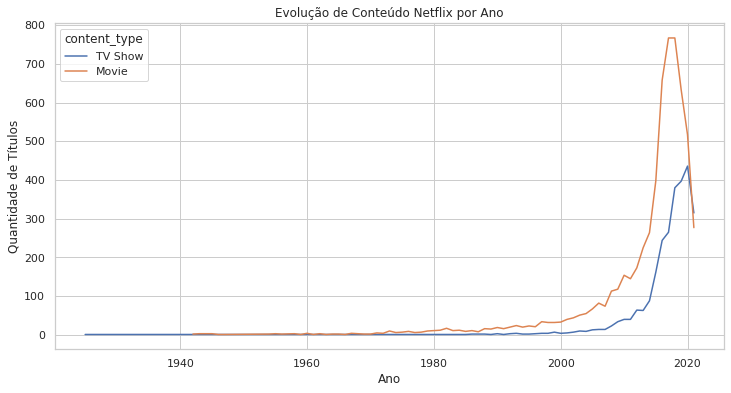

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar dados
df = spark.sql("""
SELECT f.release_year, 
       d.content_type, 
       COUNT(*) AS count
FROM gold.fato_netflix f
JOIN dim_tipo_conteudo d
    ON f.content_type_id = d.content_type_id
GROUP BY f.release_year, d.content_type
""").toPandas()

# Gráfico de evolução
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='release_year', y='count',hue='content_type')
plt.title('Evolução de Conteúdo Netflix por Ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Títulos')
display()



### Distribuição de classificações etárias

In [0]:
%sql
-- Distribuicao de calssificacoes etarias
SELECT 
    rating,
    COUNT(*) AS total_content,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentage
FROM gold.fato_netflix
GROUP BY rating
ORDER BY total_content DESC;

rating,total_content,percentage
TV-MA,3207,36.41
TV-14,2160,24.53
TV-PG,863,9.80
R,799,9.07
PG-13,490,5.56
TV-Y7,334,3.79
TV-Y,307,3.49
PG,287,3.26
TV-G,220,2.50
NR,80,0.91


In [0]:
%sql
-- Distribuição por tipo de conteúdo em forma tabular
    SELECT content_type, COUNT(*) AS contagem_tipo,
    (SELECT COUNT(*) FROM gold.fato_netflix) AS total,
    ROUND(contagem_tipo * 100.00 / total, 4) AS percentual_tipo
    FROM dim_tipo_conteudo tc
    JOIN gold.fato_netflix f on tc.content_type_id = f.content_type_id 
    GROUP BY content_type


content_type,contagem_tipo,total,percentual_tipo
TV Show,2676,8807,30.3849
Movie,6131,8807,69.6151


###Gráfico de pizza para a distribuição por tipo de conteúdo

<Figure size 720x432 with 0 Axes>

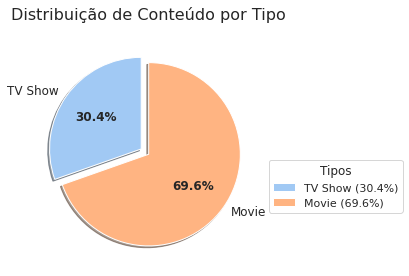

In [0]:
# Exemplo de gráfico de pizza para distribuição de tipos de conteúdo
df = spark.sql("""
    SELECT content_type, COUNT(*) AS count 
    FROM dim_tipo_conteudo tc
    JOIN gold.fato_netflix f on tc.content_type_id = f.content_type_id 
    GROUP BY content_type
""").toPandas()


# Configurar estilo do Seaborn
sns.set(style="whitegrid")

# Criar gráfico de pizza
plt.figure(figsize=(10,6))
plt.subplots()

# Definir dados e cores
labels = df['content_type']
sizes = df['count']
colors = sns.color_palette('pastel')[0:len(labels)]

# Criar o gráfico com formatação de porcentagem
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%.1f%%',
    startangle=90,
    explode=[0.1 if i == 0 else 0 for i in range(len(df))],  # Destacar primeira fatia
    shadow=True,
    textprops={'fontsize': 12}
)

# Ajustar layout
plt.setp(autotexts, size=12, weight="bold")
plt.title('Distribuição de Conteúdo por Tipo', fontsize=16, pad=20)

# Adicionar legenda com percentuais
percent = 100.*sizes/sizes.sum()
legenda_labels = [f'{l} ({p:.1f}%)' for l, p in zip(labels, percent)]
plt.legend(wedges, legenda_labels, title="Tipos", loc="best", bbox_to_anchor=(1, 0.5))

# Mostrar gráfico
plt.tight_layout()
plt.show()

###TOP 10 diretores

In [0]:
%sql
-- Os TOP 10 diretores
SELECT 
    d.director,
    COUNT(j.show_id) AS total_content
FROM gold.conteudo_diretor_junc j
JOIN gold.dim_diretor d ON j.director_id = d.director_id
GROUP BY d.director
ORDER BY total_content DESC
LIMIT 10;


director,total_content
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,15
Cathy Garcia-Molina,13
Jay Chapman,12
Martin Scorsese,12
Youssef Chahine,12


###TOP 10 atores

In [0]:
%sql
-- Os TOP 10 atores
SELECT 
    a.cast,
    COUNT(j.show_id) AS total_content
FROM silver.conteudo_ator_junc j
JOIN silver.dim_ator a ON j.ator_id = a.ator_id
GROUP BY a.cast
ORDER BY total_content DESC
LIMIT 10;


cast,total_content
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Naseeruddin Shah,32
Takahiro Sakurai,32
Rupa Bhimani,31
Akshay Kumar,30
Om Puri,30
Yuki Kaji,29
Amitabh Bachchan,28


###TOP 10 Gêneros

In [0]:
%sql
-- Os TOP 10 genero
SELECT 
    g.genre,
    COUNT(j.show_id) AS total_content
FROM silver.conteudo_genero_junc j
JOIN silver.dim_genero g ON j.genre_id = g.genre_id
GROUP BY g.genre
ORDER BY total_content DESC
LIMIT 10;


genre,total_content
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641
Romantic Movies,616


###TOP 10 Países

In [0]:
%sql
-- Os TOP 10 paises
SELECT 
    p.country,
    COUNT(j.show_id) AS total_content
FROM silver.conteudo_pais_junc j
JOIN silver.dim_pais p ON j.country_id = p.country_id
GROUP BY p.country
ORDER BY total_content DESC
LIMIT 10;


country,total_content
United States,3690
India,1046
United Kingdom,806
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226
Mexico,169


In [0]:
spark.catalog.clearCache()

In [0]:
gc.collect()

Out[193]: 7148